Import Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\Data Analysis Projects\CSV files\Cleaned CSV\Telecom_Churn_Clean.csv")

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# Binary churn column — useful throughout EDA
df['churn_binary'] = (df['churn'] == 'Yes').astype(int)

num_cols = ['tenure', 'monthly_charges', 'total_charges']
cat_cols = ['contract', 'payment_method', 'internet_service',
            'tech_support', 'online_security']

Overall Churn Rate (KPI)

Total customers  : 20,000
Churned          : 6,843  (34.2%)
Retained         : 13,157  (65.8%)


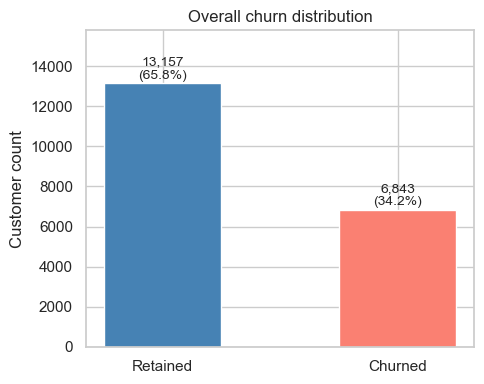

In [2]:
churn_rate = df['churn_binary'].mean() * 100
total = len(df)
churned = df['churn_binary'].sum()
retained = total - churned

print(f"Total customers  : {total:,}")
print(f"Churned          : {churned:,}  ({churn_rate:.1f}%)")
print(f"Retained         : {retained:,}  ({100-churn_rate:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Retained', 'Churned'], [retained, churned],
       color=['steelblue', 'salmon'], edgecolor='white', width=0.5)
for bar, val in zip(ax.patches, [retained, churned]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 60, f'{val:,}\n({val/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Overall churn distribution')
ax.set_ylabel('Customer count')
ax.set_ylim(0, max(retained, churned) * 1.2)
plt.tight_layout()
plt.show()

Histogram and KDE

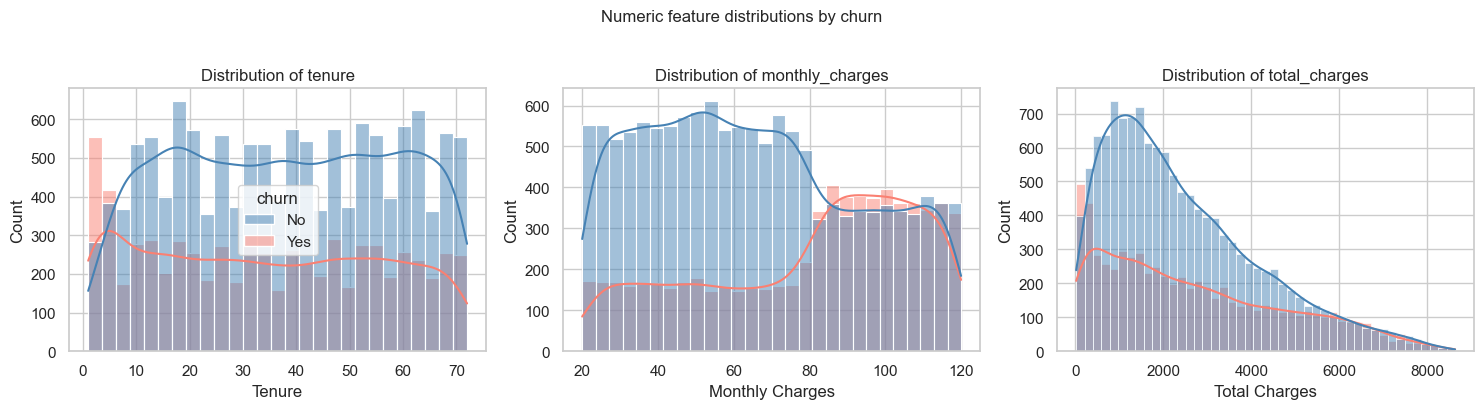

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='churn', kde=True,
                 palette={'No': 'steelblue', 'Yes': 'salmon'},
                 alpha=0.5, ax=ax, legend=(col == 'tenure'))
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col.replace('_', ' ').title())

plt.suptitle('Numeric feature distributions by churn', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Boxplots: numeric features by churn

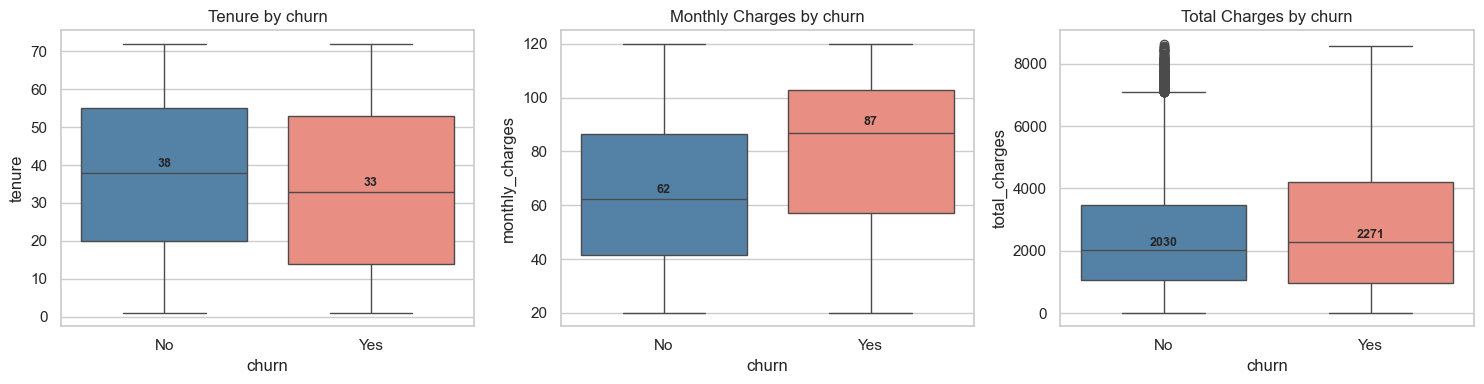

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='churn', y=col,
                hue='churn', palette={'No': 'steelblue', 'Yes': 'salmon'},
                legend=False, ax=ax)
    medians = df.groupby('churn')[col].median()
    for tick, label in enumerate(ax.get_xticklabels()):
        val = medians[label.get_text()]
        ax.text(tick, val + val * 0.02, f'{val:.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{col.replace("_"," ").title()} by churn')

plt.tight_layout()
plt.show()

Churn rate by each categorical feature

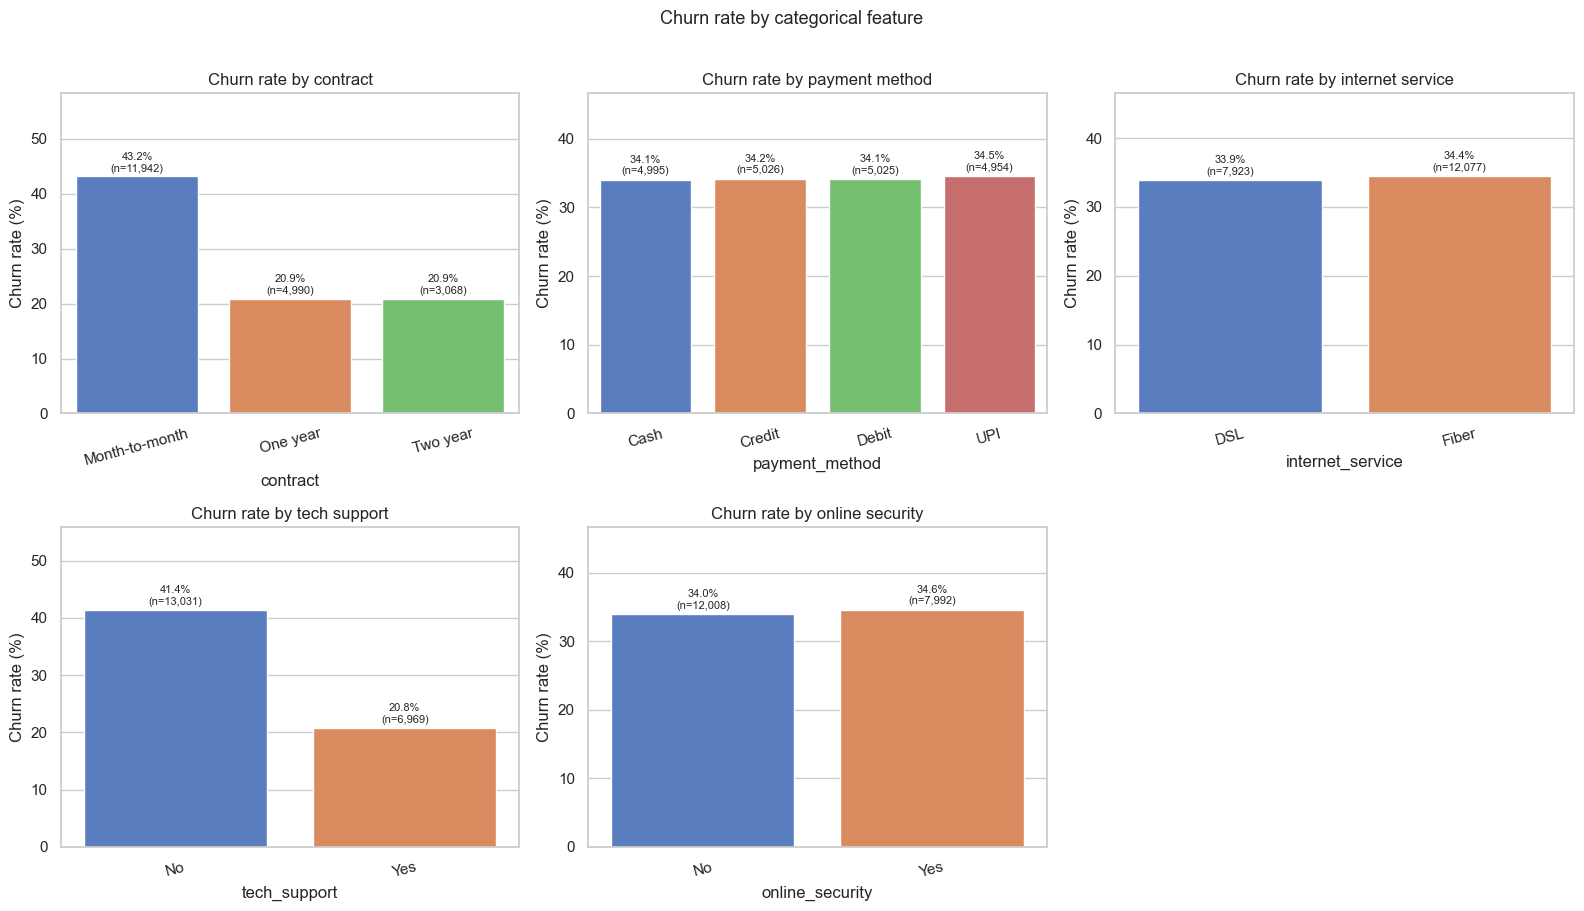

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate_by_cat = (
        df.groupby(col)['churn_binary']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'churn_rate', 'count': 'n'})
          .reset_index()
    )
    churn_rate_by_cat['churn_rate'] *= 100

    sns.barplot(data=churn_rate_by_cat, x=col, y='churn_rate',
                hue=col, palette='muted', legend=False, ax=axes[i])

    # Annotate bars with % and n
    for bar, (_, row) in zip(axes[i].patches, churn_rate_by_cat.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f"{row['churn_rate']:.1f}%\n(n={row['n']:,})",
                     ha='center', va='bottom', fontsize=8)

    axes[i].set_title(f'Churn rate by {col.replace("_"," ")}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].set_ylim(0, churn_rate_by_cat['churn_rate'].max() * 1.35)
    axes[i].tick_params(axis='x', rotation=15)

fig.delaxes(axes[-1])
plt.suptitle('Churn rate by categorical feature', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Tenure vs monthly charges

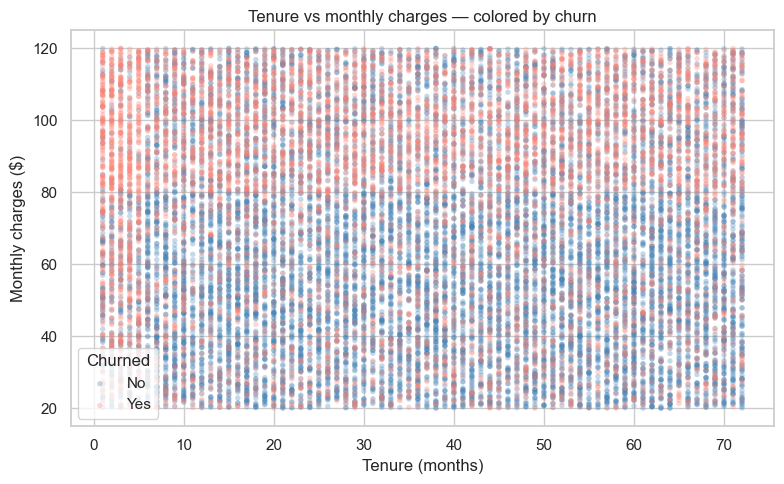

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'No': 'steelblue', 'Yes': 'salmon'}
for label, group in df.groupby('churn'):
    ax.scatter(group['tenure'], group['monthly_charges'],
               c=colors[label], label=label, alpha=0.3, s=15, edgecolors='none')

ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly charges ($)')
ax.set_title('Tenure vs monthly charges — colored by churn')
ax.legend(title='Churned', frameon=True)
plt.tight_layout()
plt.show()

Support calls vs churn rate

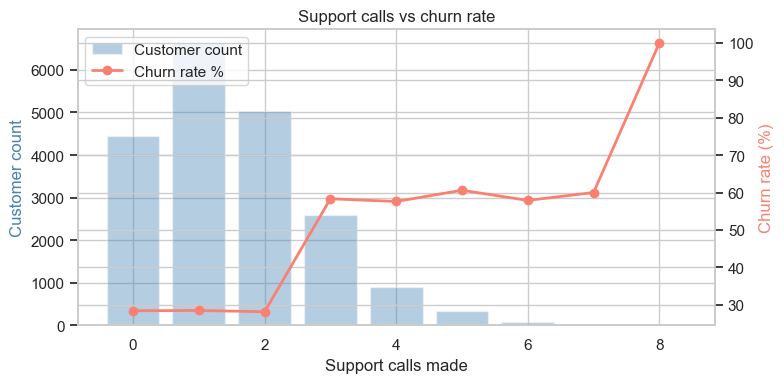

In [7]:
support_churn = (df.groupby('support_calls')['churn_binary']
                   .agg(['mean', 'count'])
                   .rename(columns={'mean': 'churn_rate', 'count': 'n'})
                   .reset_index())
support_churn['churn_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.bar(support_churn['support_calls'], support_churn['n'],
        color='steelblue', alpha=0.4, label='Customer count')
ax2.plot(support_churn['support_calls'], support_churn['churn_rate'],
         color='salmon', marker='o', linewidth=2, label='Churn rate %')

ax1.set_xlabel('Support calls made')
ax1.set_ylabel('Customer count', color='steelblue')
ax2.set_ylabel('Churn rate (%)', color='salmon')
ax1.set_title('Support calls vs churn rate')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

Correlation heatmap

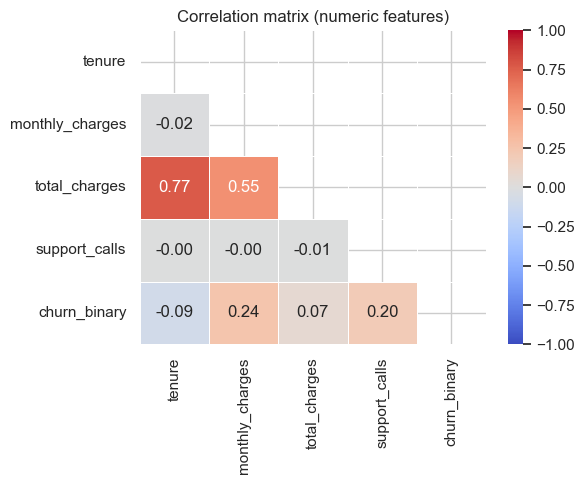

In [8]:
corr_cols = num_cols + ['support_calls', 'churn_binary']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, mask=mask, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

Key findings summary

In [9]:
print("=" * 50)
print("EDA KEY FINDINGS")
print("=" * 50)

overall_churn = df['churn_binary'].mean() * 100
print(f"\nOverall churn rate: {overall_churn:.1f}%\n")

print("--- Churn rate by contract ---")
print(df.groupby('contract')['churn_binary']
        .mean().mul(100).round(1).astype(str).add('%').to_string())

print("\n--- Median tenure: churned vs retained ---")
print(df.groupby('churn')['tenure']
        .median().round(1).to_string())

print("\n--- Median monthly charges: churned vs retained ---")
print(df.groupby('churn')['monthly_charges']
        .median().round(2).to_string())

print("\n--- Churn rate by tech support ---")
print(df.groupby('tech_support')['churn_binary']
        .mean().mul(100).round(1).astype(str).add('%').to_string())

print("=" * 50)

EDA KEY FINDINGS

Overall churn rate: 34.2%

--- Churn rate by contract ---
contract
Month-to-month    43.2%
One year          20.9%
Two year          20.9%

--- Median tenure: churned vs retained ---
churn
No     38.0
Yes    33.0

--- Median monthly charges: churned vs retained ---
churn
No     62.33
Yes    86.89

--- Churn rate by tech support ---
tech_support
No     41.4%
Yes    20.8%
